# Chips Sales Analysis

### This notebook analyzes customer purchasing behaviour and evaluates the impact of a store trial conducted in selected stores.

### The analysis is divided into two main tasks:

### Task 1  
### Exploratory data analysis to understand customer segments and purchasing patterns.

### Task 2  
### Retail experimentation analysis to evaluate whether a store trial increased chip sales.

### Tools used:
### - Python
### - Pandas
### - Matplotlib

In [1]:
# Import required libraries
# pandas -> data manipulation
# matplotlib -> visualization

import pandas as pd
from matplotlib import pyplot as plt

In [2]:
# Load datasets
# df_pur -> customer demographic and purchase behaviour data
# df_cust -> transaction level data for chip purchases

df_pur = pd.read_csv("QVI_purchase_behaviour.csv")
df_cust = pd.read_excel("QVI_transaction_data.xlsx")

In [3]:
df_pur.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [4]:
df_cust.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [5]:
# Convert Excel serial date format into proper datetime format

df_cust['DATE'] = pd.to_datetime(df_cust["DATE"], unit = "D", origin = "1899-12-30")

In [6]:
## Data Quality Checks

## We check for:
## - Missing values
## - Duplicates
## - Data consistency

df_cust.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [7]:
df_pur.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [8]:
df_cust.duplicated().sum()

1

In [9]:
df_pur.duplicated().sum()

0

In [10]:
# Remove duplicate transaction records

df_cust.drop_duplicates(inplace = True)

In [11]:
# Calculate price per unit of chips

df_cust["price_per_unit"] = df_cust["TOT_SALES"] / df_cust["PROD_QTY"]

df_cust["price_per_unit"].describe()

count    264835.000000
mean          3.824628
std           1.109524
min           1.320000
25%           3.000000
50%           3.800000
75%           4.600000
max           6.500000
Name: price_per_unit, dtype: float64

In [12]:
## Detect unusual transactions

## We check for extremely large purchase quantities that may represent data errors or bulk purchases.

df_cust["PROD_QTY"].describe()

count    264835.000000
mean          1.907308
std           0.643655
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64

In [13]:
df_cust["TOT_SALES"].describe()

count    264835.000000
mean          7.304205
std           3.083231
min           1.500000
25%           5.400000
50%           7.400000
75%           9.200000
max         650.000000
Name: TOT_SALES, dtype: float64

In [14]:
filt = df_cust["PROD_QTY"] > 20
df_cust[filt]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,price_per_unit
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,3.25
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,3.25


In [15]:
filt = df_cust['LYLTY_CARD_NBR'] == 226000
df_cust[filt]["PROD_QTY"].sum()

400

In [16]:
df_cust[df_cust["PROD_QTY"] > 20]["LYLTY_CARD_NBR"].value_counts()

226000    2
Name: LYLTY_CARD_NBR, dtype: int64

In [17]:
filt = df_cust["LYLTY_CARD_NBR"] == 226000
df_cust.drop(index = df_cust[filt].index, inplace = True)

In [18]:
df_pur['PREMIUM_CUSTOMER'].value_counts()

Mainstream    29245
Budget        24470
Premium       18922
Name: PREMIUM_CUSTOMER, dtype: int64

In [19]:
df_pur.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [20]:
df_pur["LYLTY_CARD_NBR"].duplicated().sum()

0

In [21]:
df_cust["LYLTY_CARD_NBR"].duplicated().sum()

192197

In [22]:
# Merge transaction data with customer demographic data

df_final = pd.merge(df_cust, df_pur, on = "LYLTY_CARD_NBR", how = "left")

# Task 1: Customer and Sales Analysis

### In this section we explore customer segments and purchasing behaviour.

### Key questions:
### - Which customer segments generate the most sales?
### - How do purchasing patterns differ across customer groups?

In [23]:
df_final.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,price_per_unit,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,3.00,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,2.10,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,1.45,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,3.00,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,4.60,MIDAGE SINGLES/COUPLES,Budget


In [24]:
df_final.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
price_per_unit      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [25]:
round(df_final["TOT_SALES"].sum())

1933109

In [26]:
round(df_final["PROD_QTY"].sum())

504722

In [27]:
# Total chip sales by customer life stage

sales_by_lifestage = df_final.groupby(["LIFESTAGE"])["TOT_SALES"].sum().sort_values(ascending = False)

In [28]:
sales_by_lifestage

LIFESTAGE
OLDER SINGLES/COUPLES     402420.75
RETIREES                  366470.90
OLDER FAMILIES            352467.20
YOUNG FAMILIES            316160.10
YOUNG SINGLES/COUPLES     260405.30
MIDAGE SINGLES/COUPLES    184751.30
NEW FAMILIES               50433.45
Name: TOT_SALES, dtype: float64

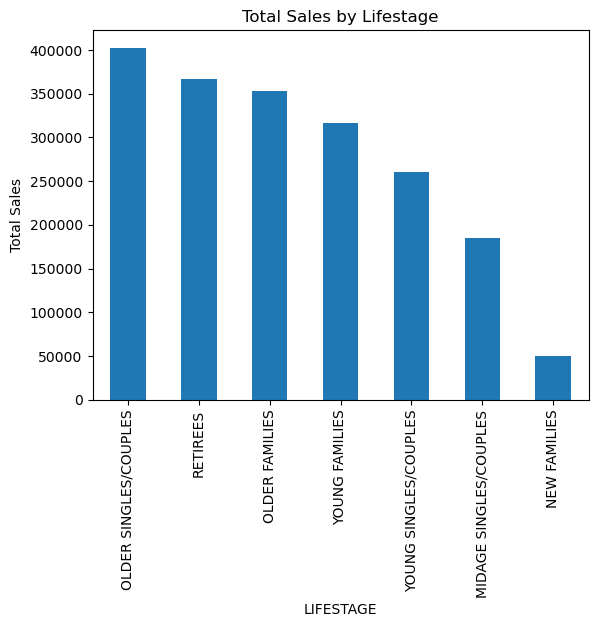

In [29]:
### Sales by Customer Life Stage

sales_by_lifestage.plot(kind="bar")
plt.title("Total Sales by Lifestage")
plt.ylabel("Total Sales")
plt.show()

In [30]:
sales_by_primium_customer = df_final.groupby("PREMIUM_CUSTOMER")["TOT_SALES"].sum().sort_values(ascending = False)
sales_by_primium_customer

PREMIUM_CUSTOMER
Mainstream    750744.50
Budget        676211.55
Premium       506152.95
Name: TOT_SALES, dtype: float64

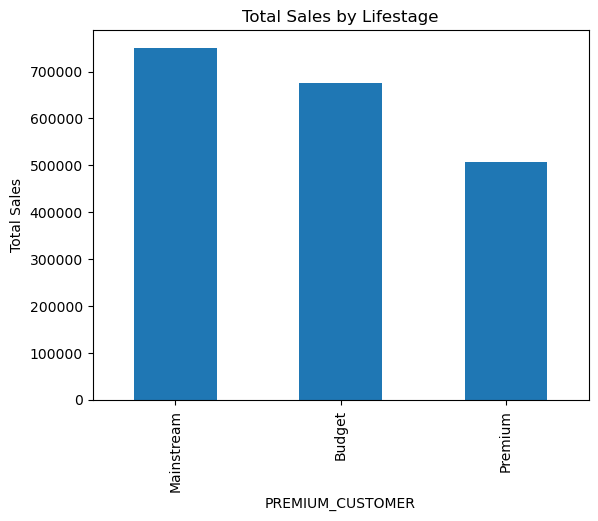

In [31]:
sales_by_primium_customer.plot(kind = "bar")
plt.title("Total Sales by Lifestage")
plt.ylabel("Total Sales")
plt.show()

In [32]:
df_final.groupby("LIFESTAGE")["LYLTY_CARD_NBR"].nunique().sort_values(ascending=False)

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9779
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: LYLTY_CARD_NBR, dtype: int64

In [33]:
sales_per_customer = df_final.groupby("LIFESTAGE").agg(
    total_sales=("TOT_SALES", "sum"),
    customers=("LYLTY_CARD_NBR", "nunique")
)

sales_per_customer["avg_sales_per_customer"] = (
    sales_per_customer["total_sales"] / sales_per_customer["customers"]
)

sales_per_customer.sort_values("avg_sales_per_customer", ascending=False)

,total_sales,customers,avg_sales_per_customer
LIFESTAGE,,,
OLDER FAMILIES,352467.20,9779,36.043276
YOUNG FAMILIES,316160.10,9178,34.447603
OLDER SINGLES/COUPLES,402420.75,14609,27.546085
MIDAGE SINGLES/COUPLES,184751.30,7275,25.395368
RETIREES,366470.90,14805,24.753185
NEW FAMILIES,50433.45,2549,19.785583
YOUNG SINGLES/COUPLES,260405.30,14441,18.032359


In [34]:
avg_qty_per_lifestage = df_final.groupby("LIFESTAGE")["PROD_QTY"].mean().sort_values(ascending=False)
avg_qty_per_lifestage

LIFESTAGE
OLDER FAMILIES            1.946578
YOUNG FAMILIES            1.939828
OLDER SINGLES/COUPLES     1.912717
MIDAGE SINGLES/COUPLES    1.900478
RETIREES                  1.892289
NEW FAMILIES              1.856771
YOUNG SINGLES/COUPLES     1.831762
Name: PROD_QTY, dtype: float64

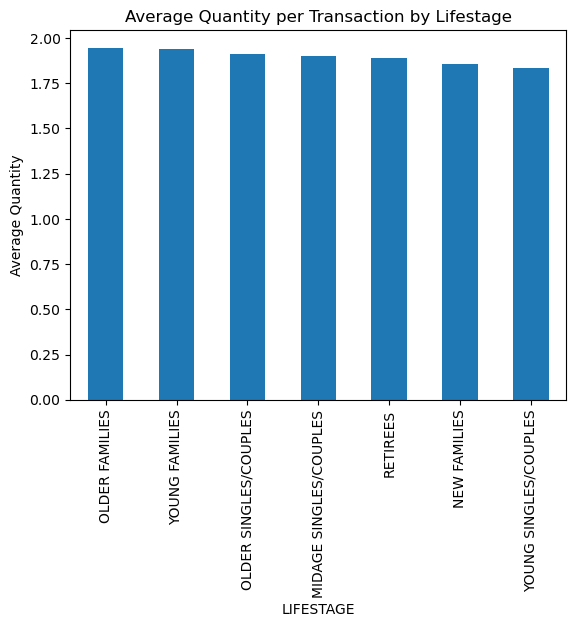

In [35]:
avg_qty_per_lifestage.plot(kind="bar", title="Average Quantity per Transaction by Lifestage")
plt.ylabel("Average Quantity")
plt.show()

In [36]:
avg_price_per_lifestage = df_final.groupby("LIFESTAGE")["price_per_unit"].mean().sort_values(ascending=False)
avg_price_per_lifestage

LIFESTAGE
NEW FAMILIES              3.907443
YOUNG SINGLES/COUPLES     3.887723
RETIREES                  3.884459
MIDAGE SINGLES/COUPLES    3.864922
OLDER SINGLES/COUPLES     3.855741
YOUNG FAMILIES            3.739539
OLDER FAMILIES            3.724983
Name: price_per_unit, dtype: float64

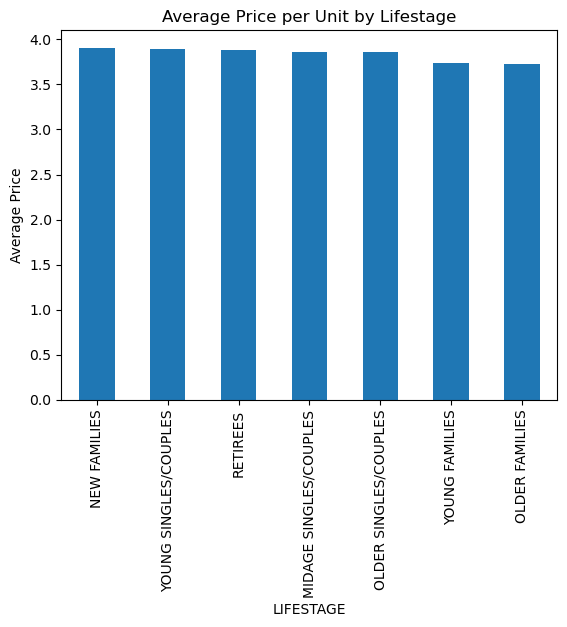

In [37]:
avg_price_per_lifestage.plot(kind="bar", title="Average Price per Unit by Lifestage")
plt.ylabel("Average Price")
plt.show()

In [38]:
txns_per_customer = df_final.groupby(["LIFESTAGE","LYLTY_CARD_NBR"])["TXN_ID"].count().groupby("LIFESTAGE").mean()
txns_per_customer = txns_per_customer.sort_values(ascending=False)
txns_per_customer

LIFESTAGE
OLDER FAMILIES            4.969220
YOUNG FAMILIES            4.749619
OLDER SINGLES/COUPLES     3.729071
MIDAGE SINGLES/COUPLES    3.451546
RETIREES                  3.361229
NEW FAMILIES              2.714398
YOUNG SINGLES/COUPLES     2.519008
Name: TXN_ID, dtype: float64

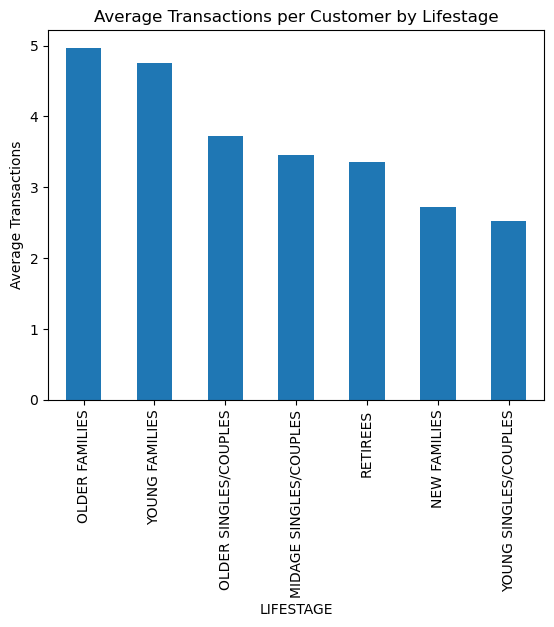

In [39]:
txns_per_customer.plot(kind="bar", title="Average Transactions per Customer by Lifestage")
plt.ylabel("Average Transactions")
plt.show()

# Task 2: Retail Experimentation Analysis

### Three stores (77, 86 and 88) participated in a trial aimed at increasing chip sales.

### To evaluate the trial we:
### 1. Identify a control store similar to each trial store
### 2. Estimate expected sales using the control store
### 3. Compare actual vs expected performance
### 4. Measure incremental sales during the trial period

In [40]:
df = pd.read_csv("QVI_data.csv")
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


### Control Store Selection

In [42]:
# Create monthly period column for time series analysis

df["DATE"] = pd.to_datetime(df["DATE"])
df["Year_Month"] = df["DATE"].dt.to_period("M")

In [43]:
# Create monthly metrics per store:
# - Total sales
# - Number of customers
# - Number of transactions
# - Quantity sold

store_monthly = df.groupby(["STORE_NBR", "Year_Month"]).agg(
    Total_sales = ("TOT_SALES", "sum"),
    num_customers = ("LYLTY_CARD_NBR", "nunique"),
    num_transaction = ("TXN_ID", "nunique"),
    qty = ("PROD_QTY", "sum")
).reset_index()

In [44]:
store_monthly["txn_per_customer"] = (
    store_monthly["num_transaction"] / store_monthly["num_customers"]
)
store_monthly.head()

,STORE_NBR,Year_Month,Total_sales,num_customers,num_transaction,qty,txn_per_customer
0,1,2018-07,206.9,49,52,62,1.061224
1,1,2018-08,176.1,42,43,54,1.023810
2,1,2018-09,278.8,59,62,75,1.050847
3,1,2018-10,188.1,44,45,58,1.022727
4,1,2018-11,192.6,46,47,57,1.021739


In [45]:
# pre- trail filter
filt = (store_monthly["Year_Month"] >= "2018-07") & (store_monthly["Year_Month"] <= "2019-01")
pre_trial = store_monthly[filt]
pre_trial.head()

,STORE_NBR,Year_Month,Total_sales,num_customers,num_transaction,qty,txn_per_customer
0,1,2018-07,206.9,49,52,62,1.061224
1,1,2018-08,176.1,42,43,54,1.023810
2,1,2018-09,278.8,59,62,75,1.050847
3,1,2018-10,188.1,44,45,58,1.022727
4,1,2018-11,192.6,46,47,57,1.021739


In [46]:
pre_trial["STORE_NBR"].nunique()

271

In [47]:
pre_trial.shape

(1848, 7)

## Control Store Selection

### A control store should behave similarly to the trial store during the pre-trial period.

### Similarity is measured using:
### - correlation
### - Magnitude distance

In [48]:
# This function identifies the most similar control stores
# based on a chosen metric (sales, customers, transactions or quantity)

def control_store(store_id, metric):
    sales_pivot = pre_trial.pivot_table(
    index = "Year_Month",
    columns = "STORE_NBR",
    values = metric)
        
    correlation = sales_pivot.corr()[store_id]
    
    diff = abs(sales_pivot.sub(sales_pivot[store_id], axis=0))
    dist = diff.mean()
    
    mag = 1 - (dist - dist.min()) / (dist.max() - dist.min())
        
    correlation = correlation.drop(store_id)
    mag = mag.drop(store_id)
    
    score_df = pd.DataFrame({
    "correlation": correlation,
    "magnitude": mag})
    score_df["final_score"] = (score_df["correlation"] + score_df["magnitude"]) / 2
    
    return score_df.sort_values("final_score", ascending=False).head(10)

In [49]:
# This function evaluates the trial impact by:
# 1. Calculating expected sales using a scaling factor
# 2. Comparing actual vs expected sales
# 3. Calculating incremental sales during the trial period

def trial_analysis(trial_store, control_store, metric = "TOT_SALES"):
    Trial_df = df[df["STORE_NBR"].isin([trial_store,control_store])]
    Trial_sales = Trial_df.groupby(
    ["Year_Month","STORE_NBR"]
    )[metric].sum().unstack()
    pre_trial_mask = Trial_sales.index < "2019-02"
    avg1 = Trial_sales.loc[pre_trial_mask, trial_store].mean()
    avg2 = Trial_sales.loc[pre_trial_mask, control_store].mean()
    scaling_factor = avg1 / avg2
    expected_sales = Trial_sales[control_store] * scaling_factor
    comparison = pd.DataFrame({
    "Actual" : Trial_sales[trial_store],
    "Expected": expected_sales
    })
    comparison["incremental_sales"] = comparison["Actual"] - comparison["Expected"]
    return comparison, Trial_sales

## Trial Store 77 Analysis

In [50]:
store_77 = control_store(77, "Total_sales")
store_77

,correlation,magnitude,final_score
STORE_NBR,,,
233,0.903774,0.984567,0.944171
31,1.000000,0.813241,0.906620
11,1.000000,0.809389,0.904694
41,0.783232,0.962834,0.873033
50,0.763866,0.971546,0.867706
17,0.842668,0.872450,0.857559
115,0.689159,0.928151,0.808655
167,0.657110,0.956160,0.806635
265,0.639759,0.960434,0.800097


In [51]:
store_77 = control_store(77, "num_customers")
store_77

,correlation,magnitude,final_score
STORE_NBR,,,
233,0.990358,0.992343,0.991350
254,0.916208,0.934150,0.925179
41,0.844219,0.973966,0.909093
84,0.858571,0.920368,0.889469
17,0.747308,0.961715,0.854511
115,0.718882,0.963247,0.841064
35,0.774647,0.903522,0.839085
167,0.717913,0.947933,0.832923
111,0.685926,0.964778,0.825352


In [52]:
store_77 = control_store(77, "num_transaction")
store_77

,correlation,magnitude,final_score
STORE_NBR,,,
233,0.958422,0.982517,0.970470
41,0.843928,0.979021,0.911475
254,0.865382,0.951049,0.908216
17,0.808263,0.973193,0.890728
115,0.768323,0.969697,0.869010
111,0.666728,0.973193,0.819961
35,0.726086,0.911422,0.818754
27,0.672215,0.961538,0.816877
167,0.678943,0.953380,0.816161


In [53]:
store_77 = control_store(77, "qty")
store_77

,correlation,magnitude,final_score
STORE_NBR,,,
233,0.820381,0.978518,0.899449
121,0.802161,0.916219,0.859190
27,0.814323,0.901719,0.858021
41,0.737611,0.950054,0.843832
17,0.715924,0.926960,0.821442
254,0.711776,0.896885,0.804330
115,0.663117,0.911923,0.787520
167,0.630733,0.940387,0.785560
264,0.581709,0.960795,0.771252


In [54]:
comparison77, actual_77 = trial_analysis(77, 233)
comparison77

,Actual,Expected,incremental_sales
Year_Month,,,
2018-07,296.8,297.565550,-0.765550
2018-08,255.5,292.652187,-37.152187
2018-09,225.2,233.998916,-8.798916
2018-10,204.5,190.085733,14.414267
2018-11,245.3,216.597421,28.702579
2018-12,267.3,286.408121,-19.108121
2019-01,204.4,181.692071,22.707929
2019-02,235.0,249.762622,-14.762622
2019-03,278.5,203.802205,74.697795


In [55]:
comparison77.loc["2019-03":"2019-04","incremental_sales"].sum() 

175.8520906133268

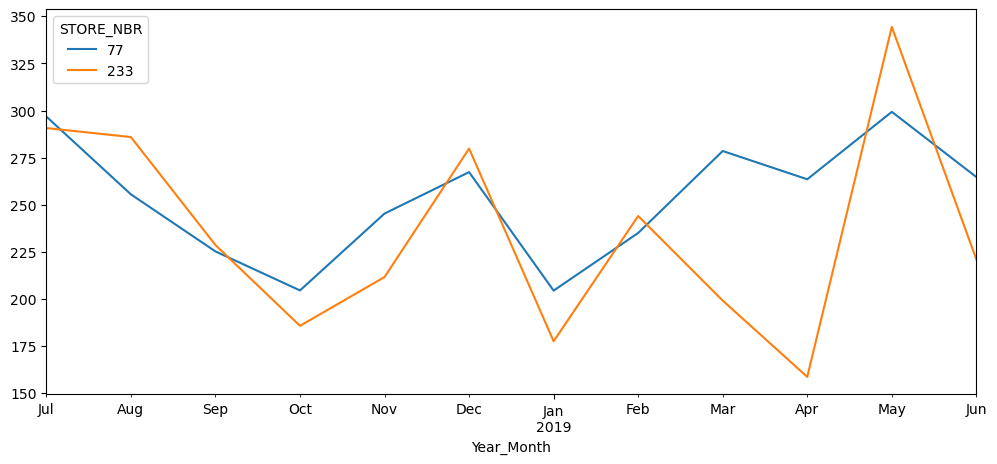

In [56]:
actual_77.plot(figsize = (12,5))
plt.show()

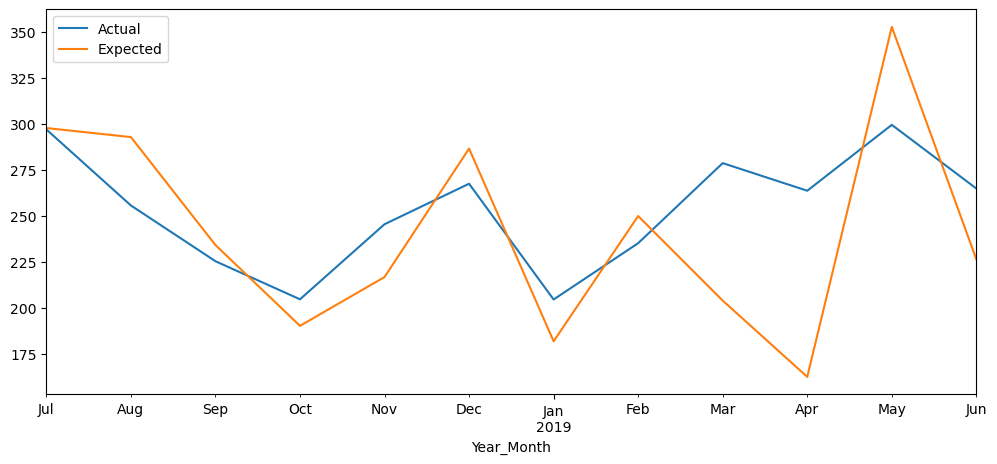

In [57]:
del comparison77['incremental_sales']
comparison77.plot(figsize = (12,5))
plt.show()

#### Store 233 was selected as the control store for Store 77 based on similarity in sales, customers, transactions and quantity during the pre-trial period.

#### During the trial period (March–April 2019), Store 77 recorded significantly higher sales than expected when compared to the scaled control store.

#### This resulted in approximately 175 units of incremental sales, indicating that the trial had a positive impact on store performance.

## Trial Store 86 Analysis

In [58]:
store_86 = control_store(86, "Total_sales")
store_86

,correlation,magnitude,final_score
STORE_NBR,,,
155,0.877882,0.965551,0.921717
222,0.795075,0.961944,0.878509
109,0.788300,0.966461,0.877380
138,0.759864,0.930565,0.845214
114,0.734415,0.927040,0.830728
269,0.697055,0.908766,0.802911
106,0.678684,0.916960,0.797822
225,0.617533,0.960170,0.788851
128,0.654929,0.874932,0.764930


In [59]:
store_86 = control_store(86, "num_customers")
store_86

,correlation,magnitude,final_score
STORE_NBR,,,
155,0.942876,0.986772,0.964824
114,0.855339,0.941799,0.898569
109,0.770778,0.969577,0.870177
225,0.733791,0.969577,0.851684
138,0.749701,0.935185,0.842443
147,0.641090,0.923280,0.782185
56,0.703549,0.857143,0.780346
262,0.629486,0.892857,0.761172
172,0.571024,0.940476,0.755750


In [60]:
store_86 = control_store(86, "qty")
store_86

,correlation,magnitude,final_score
STORE_NBR,,,
138,0.894762,0.945777,0.920270
75,0.849881,0.976017,0.912949
147,0.856792,0.938999,0.897895
247,0.811503,0.961940,0.886721
114,0.810371,0.940563,0.875467
155,0.751529,0.959854,0.855691
101,0.752259,0.954119,0.853189
49,0.749054,0.952033,0.850543
231,0.703964,0.961940,0.832952


In [61]:
store_86 = control_store(86, "num_transaction")
store_86

,correlation,magnitude,final_score
STORE_NBR,,,
138,0.819280,0.942649,0.880964
147,0.799353,0.939520,0.869437
166,0.765179,0.965589,0.865384
247,0.718834,0.960375,0.839605
49,0.690542,0.948905,0.819723
231,0.652028,0.963504,0.807766
137,0.682844,0.925965,0.804404
114,0.660776,0.938478,0.799627
155,0.642294,0.956204,0.799249


In [62]:
# تم اختيار 155 ك control store لان الاولويه الى sales

In [63]:
comparison86, actual_86 = trial_analysis(86, 155)
comparison86

,Actual,Expected,incremental_sales
Year_Month,,,
2018-07,892.20,896.922236,-4.722236
2018-08,764.05,759.269991,4.780009
2018-09,914.60,984.034086,-69.434086
2018-10,948.40,934.948790,13.451210
2018-11,918.00,871.894555,46.105445
2018-12,841.20,824.361363,16.838637
2019-01,841.40,848.418979,-7.018979
2019-02,913.20,864.522060,48.677940
2019-03,1026.80,780.320405,246.479595


In [64]:
comparison86.loc["2019-03":"2019-04","incremental_sales"].sum() 

275.36257073565116

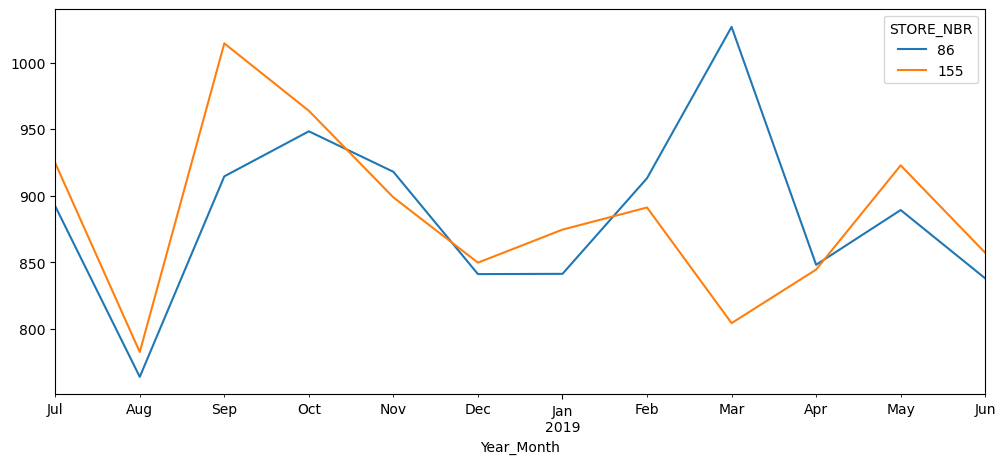

In [65]:
actual_86.plot(figsize = (12,5))
plt.show()

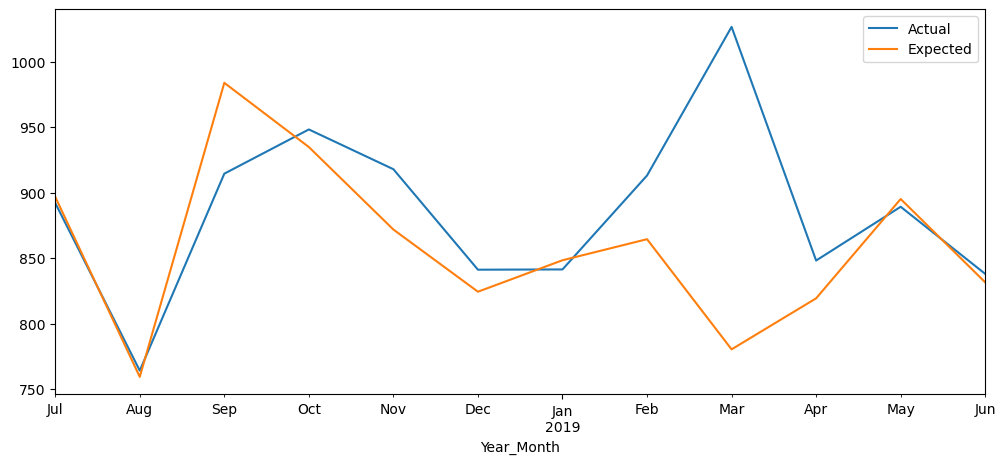

In [66]:
del comparison86['incremental_sales']
comparison86.plot(figsize = (12,5))
plt.show()

#### Store 155 was selected as the control store for Store 86 based on similarity in sales and customer behaviour during the pre-trial period.

#### A scaling factor was applied to the control store to estimate the expected performance of Store 86 if the trial had not taken place.

#### During the trial period (March–April 2019), Store 86 recorded higher sales than expected in March, although April showed slightly lower sales than the expected baseline.

#### Overall, the trial resulted in approximately 143 units of incremental sales, indicating a modest positive impact of the trial on store performance.


## Trial Store 88 Analysis

In [67]:
store_88 = control_store(88, "Total_sales")
store_88

,correlation,magnitude,final_score
STORE_NBR,,,
125,0.624109,0.859154,0.741632
203,0.508001,0.952633,0.730317
91,0.776688,0.677166,0.726927
178,0.731857,0.709362,0.720609
7,0.649657,0.788084,0.718871
201,0.492735,0.878364,0.685550
106,0.644724,0.713656,0.679190
79,0.576960,0.770645,0.673803
155,0.600771,0.685223,0.642997


In [68]:
store_88 = control_store(88, "num_customers")
store_88

,correlation,magnitude,final_score
STORE_NBR,,,
237,0.947326,0.987912,0.967619
178,0.939466,0.829670,0.884568
69,0.815792,0.875824,0.845808
113,0.862632,0.794505,0.828569
119,0.775468,0.789011,0.782239
39,0.768465,0.786813,0.777639
257,0.703602,0.849451,0.776526
123,0.627925,0.900000,0.763963
57,0.716130,0.801099,0.758614


In [69]:
store_88 = control_store(88, "num_transaction")
store_88

,correlation,magnitude,final_score
STORE_NBR,,,
123,0.906737,0.868062,0.887399
7,0.946829,0.804368,0.875599
237,0.723230,0.958144,0.840687
113,0.693233,0.848954,0.771093
203,0.573341,0.942675,0.758008
178,0.609157,0.865332,0.737245
97,0.611288,0.847134,0.729211
69,0.556328,0.897179,0.726754
94,0.524508,0.916288,0.720398


In [70]:
store_88 = control_store(88, "qty")
store_88

,correlation,magnitude,final_score
STORE_NBR,,,
155,0.758963,0.844404,0.801683
178,0.726331,0.871702,0.799016
128,0.633686,0.934941,0.784314
114,0.691996,0.867607,0.779802
106,0.644010,0.874431,0.759221
123,0.617791,0.857598,0.737695
203,0.521821,0.941765,0.731793
225,0.633793,0.819836,0.726815
237,0.495408,0.957234,0.726321


In [71]:
sales = control_store(88, "Total_sales")["final_score"]
cust = control_store(88, "num_customers")["final_score"]
qty = control_store(88, "qty")["final_score"]
txn = control_store(88, "num_transaction")["final_score"]

scores = pd.concat([sales, cust, qty, txn], axis=1)
scores.columns = ["sales","customers","qty","txn"]

scores["avg_score"] = scores.mean(axis=1)

scores.sort_values("avg_score", ascending=False).head(10)

,sales,customers,qty,txn,avg_score
STORE_NBR,,,,,
237,NaN,0.967619,0.726321,0.840687,0.844876
113,NaN,0.828569,NaN,0.771093,0.799831
123,NaN,0.763963,0.737695,0.887399,0.796352
69,NaN,0.845808,NaN,0.726754,0.786281
178,0.720609,0.884568,0.799016,0.737245,0.785360
119,NaN,0.782239,NaN,NaN,0.782239
114,NaN,NaN,0.779802,NaN,0.779802
39,NaN,0.777639,NaN,NaN,0.777639
257,NaN,0.776526,NaN,NaN,0.776526


In [72]:
comparison88, actual_88 = trial_analysis(88, 237)
comparison88

,Actual,Expected,incremental_sales
Year_Month,,,
2018-07,1310.00,1450.657086,-140.657086
2018-08,1323.80,1369.931485,-46.131485
2018-09,1423.00,1324.260425,98.739575
2018-10,1352.40,1350.401097,1.998903
2018-11,1382.80,1399.777923,-16.977923
2018-12,1325.20,1266.971288,58.228712
2019-01,1266.40,1221.600696,44.799304
2019-02,1370.20,1406.989143,-36.789143
2019-03,1477.20,1210.082775,267.117225


In [73]:
comparison88.loc["2019-03":"2019-04","incremental_sales"].sum() 

500.04005977158727

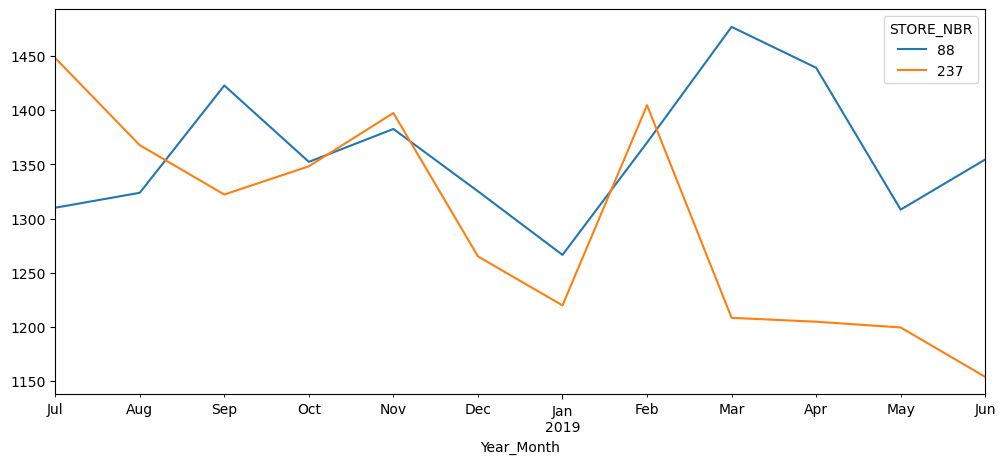

In [74]:
actual_88.plot(figsize = (12,5))
plt.show()

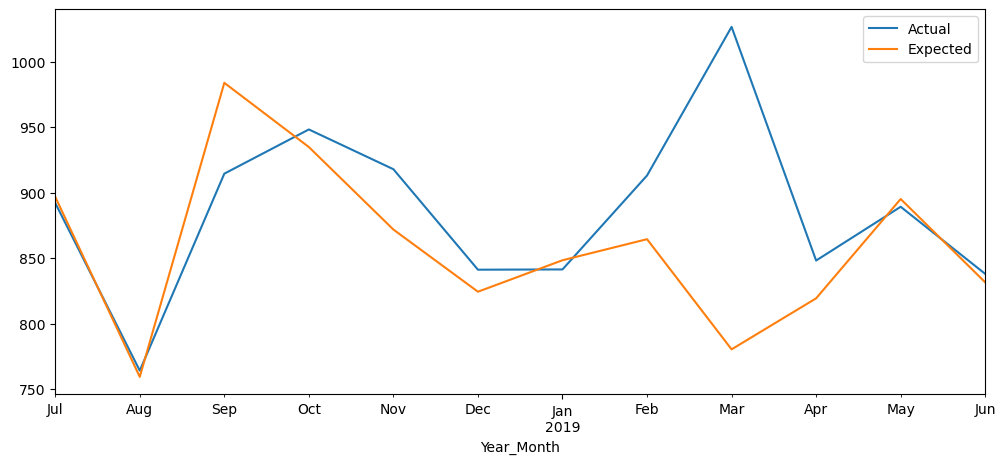

In [75]:
del comparison88['incremental_sales']
comparison86.plot(figsize = (12,5))
plt.show()

#### Store 237 was selected as the control store for Store 88 based on the overall similarity across multiple metrics including total sales, number of customers, number of transactions and product quantity during the pre-trial period.

#### To estimate the expected performance of Store 88 without the trial, a scaling factor was applied to the control store’s sales.

#### During the trial period (March–April 2019), Store 88 recorded significantly higher sales than expected when compared with the scaled control store.

#### The difference between actual and expected sales during the trial period resulted in approximately 500 units of incremental sales.

#### This indicates that the trial had a strong positive impact on the performance of Store 88.


## Final conclusion for all stores
#### The trial analysis was conducted across three stores: 77, 86 and 88. For each trial store, a suitable control store was selected based on similarity in sales performance, customer count, transaction behaviour and product quantity during the pre-trial period.

#### A scaling factor was applied to the control stores to estimate the expected sales of the trial stores if the trial had not taken place.

#### The analysis showed that all three trial stores recorded higher actual sales compared with their expected performance during the trial period (March–April 2019).

#### The incremental sales generated were approximately:

#### * 175 units for Store 77
#### * 143 units for Store 86
#### * 500 units for Store 88

#### Since all trial stores experienced a positive uplift in sales during the trial period, the trial can be considered successful.

#### Based on these results, it would be reasonable to recommend rolling out the trial strategy to additional stores.
